In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load clean data and risk scores
df = pd.read_csv('../data/processed/texas_part_d_clean.csv', low_memory=False)
provider_risk = pd.read_csv('../outputs/provider_risk_scores.csv')
watchlist = pd.read_csv('../outputs/flagged_providers_watchlist.csv')

# Plot styling
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print(f"Data loaded")
print(f"Clean data: {df.shape}")
print(f"Provider risk scores: {provider_risk.shape}")
print(f"Watchlist: {watchlist.shape}")

Data loaded
Clean data: (869717, 25)
Provider risk scores: (62301, 18)
Watchlist: (100, 18)


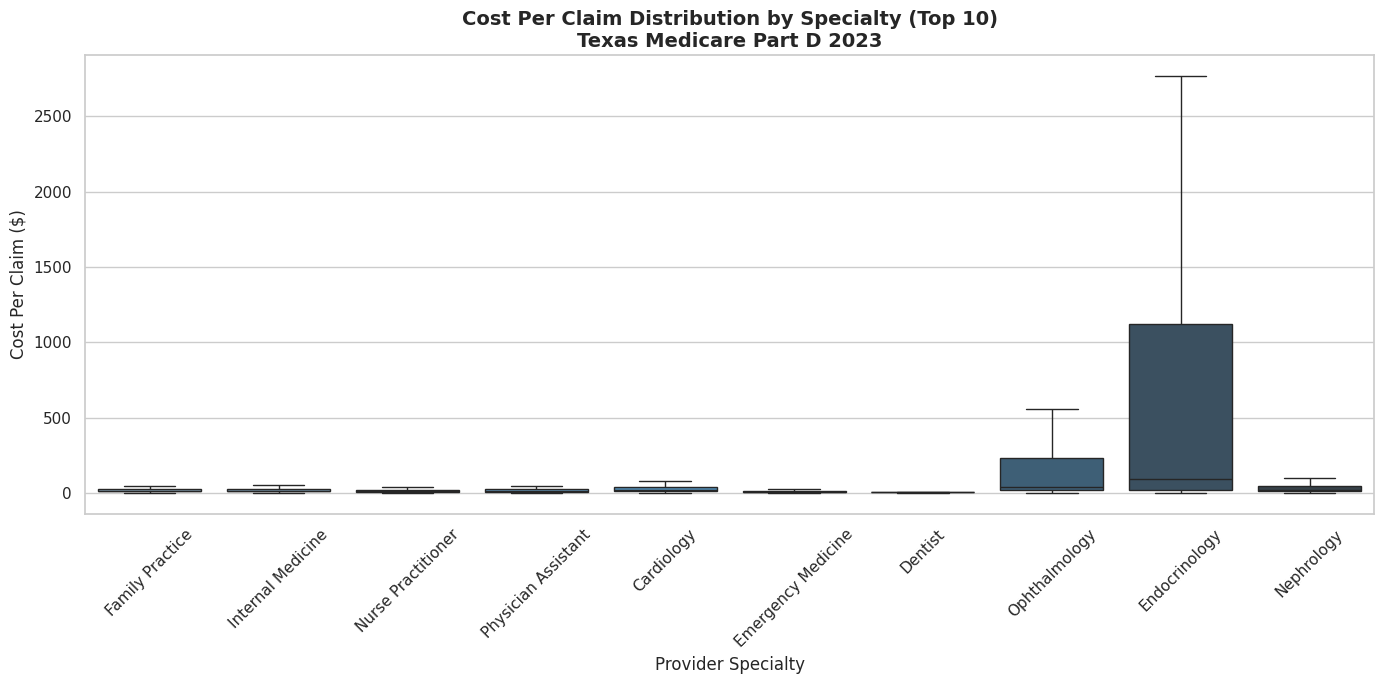

Chart saved


In [4]:
# Get top 10 specialties by provider count
top_specialties = df['Prscrbr_Type'].value_counts().head(10).index

df_top = df[df['Prscrbr_Type'].isin(top_specialties)]

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(
    data=df_top,
    x='Prscrbr_Type',
    y='cost_per_claim',
    order=top_specialties,
    showfliers=False,  # Hide extreme outliers for readability
    palette='Blues_d',
    ax=ax
)

ax.set_title('Cost Per Claim Distribution by Specialty (Top 10)\nTexas Medicare Part D 2023', 
             fontsize=14, fontweight='bold')
ax.set_xlabel('Provider Specialty', fontsize=12)
ax.set_ylabel('Cost Per Claim ($)', fontsize=12)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('../visualizations/charts/cost_per_claim_by_specialty.png', dpi=150)
plt.show()
print("Chart saved")

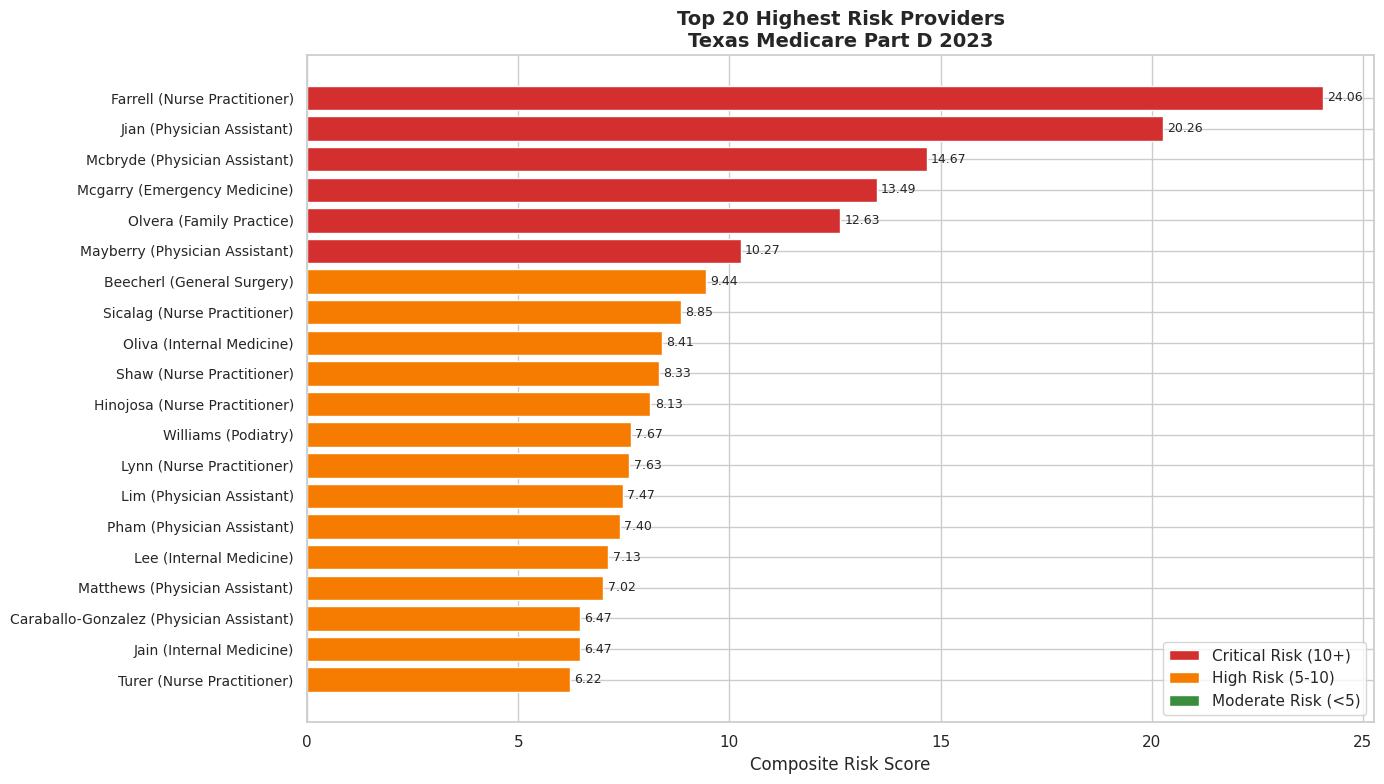

Chart saved


In [5]:
fig, ax = plt.subplots(figsize=(14, 8))

top20 = provider_risk.nlargest(20, 'risk_score')
colors = ['#d32f2f' if x >= 10 else '#f57c00' if x >= 5 else '#388e3c' 
          for x in top20['risk_score']]

bars = ax.barh(
    range(len(top20)),
    top20['risk_score'],
    color=colors
)

ax.set_yticks(range(len(top20)))
ax.set_yticklabels([
    f"{row['Prscrbr_Last_Org_Name']} ({row['Prscrbr_Type'][:20]})"
    for _, row in top20.iterrows()
], fontsize=10)

ax.set_xlabel('Composite Risk Score', fontsize=12)
ax.set_title('Top 20 Highest Risk Providers\nTexas Medicare Part D 2023',
             fontsize=14, fontweight='bold')

# Add value labels
for i, (bar, score) in enumerate(zip(bars, top20['risk_score'])):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{score:.2f}', va='center', fontsize=9)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d32f2f', label='Critical Risk (10+)'),
    Patch(facecolor='#f57c00', label='High Risk (5-10)'),
    Patch(facecolor='#388e3c', label='Moderate Risk (<5)')
]
ax.legend(handles=legend_elements, loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../visualizations/charts/top20_risk_providers.png', dpi=150)
plt.show()
print("Chart saved")

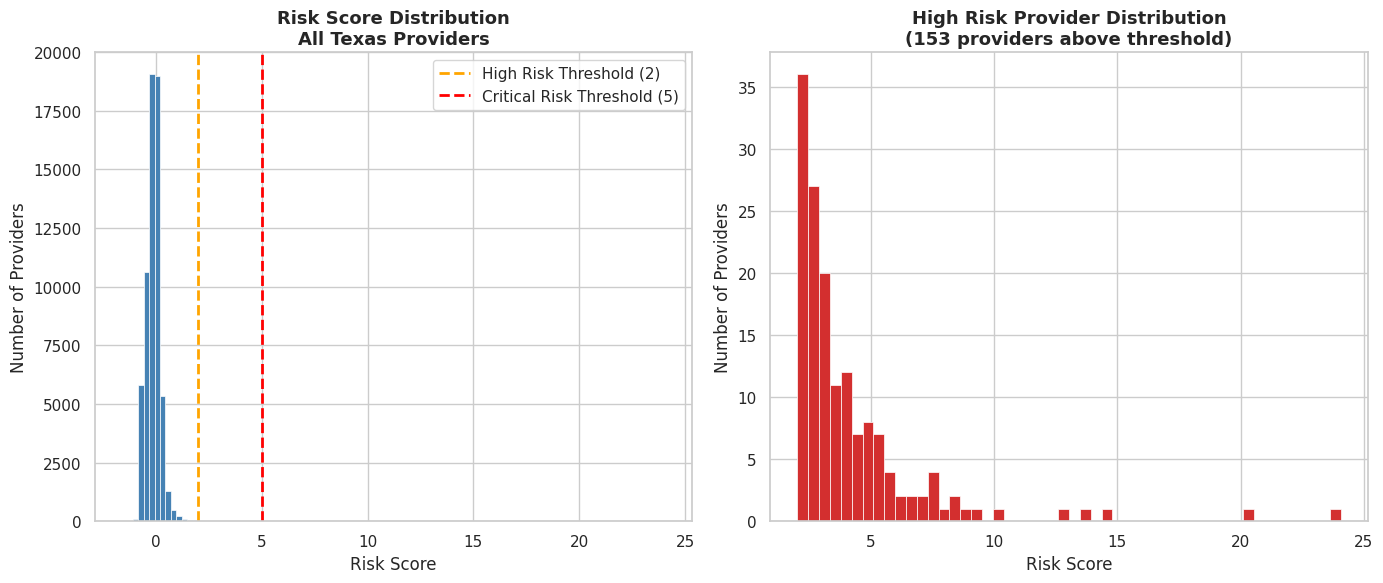

Chart saved


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Full distribution
axes[0].hist(provider_risk['risk_score'], bins=100, 
             color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(x=2, color='orange', linestyle='--', 
                linewidth=2, label='High Risk Threshold (2)')
axes[0].axvline(x=5, color='red', linestyle='--', 
                linewidth=2, label='Critical Risk Threshold (5)')
axes[0].set_title('Risk Score Distribution\nAll Texas Providers', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Risk Score')
axes[0].set_ylabel('Number of Providers')
axes[0].legend()

# Right: Zoomed into high risk tail
high_risk = provider_risk[provider_risk['risk_score'] > 2]
axes[1].hist(high_risk['risk_score'], bins=50,
             color='#d32f2f', edgecolor='white', linewidth=0.5)
axes[1].set_title(f'High Risk Provider Distribution\n({len(high_risk)} providers above threshold)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Risk Score')
axes[1].set_ylabel('Number of Providers')

plt.tight_layout()
plt.savefig('../visualizations/charts/risk_score_distribution.png', dpi=150)
plt.show()
print("Chart saved")

In [7]:
# Define expected drug categories by specialty
# Flag when a provider prescribes drugs typically outside their specialty
specialty_drug_flags = {
    'Dentist': ['insulin', 'metformin', 'lisinopril', 'atorvastatin'],
    'Ophthalmology': ['oxycodone', 'hydrocodone', 'morphine', 'fentanyl'],
    'Podiatry': ['chemotherapy', 'cladribine', 'ustekinumab']
}

mismatch_rows = []

for specialty, flagged_drugs in specialty_drug_flags.items():
    specialty_df = df[df['Prscrbr_Type'] == specialty].copy()
    for drug in flagged_drugs:
        matches = specialty_df[
            specialty_df['Gnrc_Name'].str.lower().str.contains(drug, na=False)
        ]
        if len(matches) > 0:
            mismatch_rows.append({
                'specialty': specialty,
                'unexpected_drug': drug,
                'prescribing_providers': matches['Prscrbr_NPI'].nunique(),
                'total_claims': matches['Tot_Clms'].sum(),
                'total_cost': matches['Tot_Drug_Cst'].sum()
            })

mismatch_df = pd.DataFrame(mismatch_rows)
if len(mismatch_df) > 0:
    print("Specialty mismatch findings:")
    print(mismatch_df.to_string(index=False))
else:
    print("No exact matches found - trying broader search")
    dentist_opioids = df[
        (df['Prscrbr_Type'] == 'Dentist') &
        (df['Gnrc_Name'].str.lower().str.contains('oxycodone|hydrocodone|fentanyl', na=False))
    ]
    print(f"Dentists prescribing opioids: {dentist_opioids['Prscrbr_NPI'].nunique()} providers")
    print(f"Total claims: {dentist_opioids['Tot_Clms'].sum()}")
    print(f"Total cost: ${dentist_opioids['Tot_Drug_Cst'].sum():,.2f}")

Specialty mismatch findings:
    specialty unexpected_drug  prescribing_providers  total_claims  total_cost
Ophthalmology     hydrocodone                     16           734     6236.15


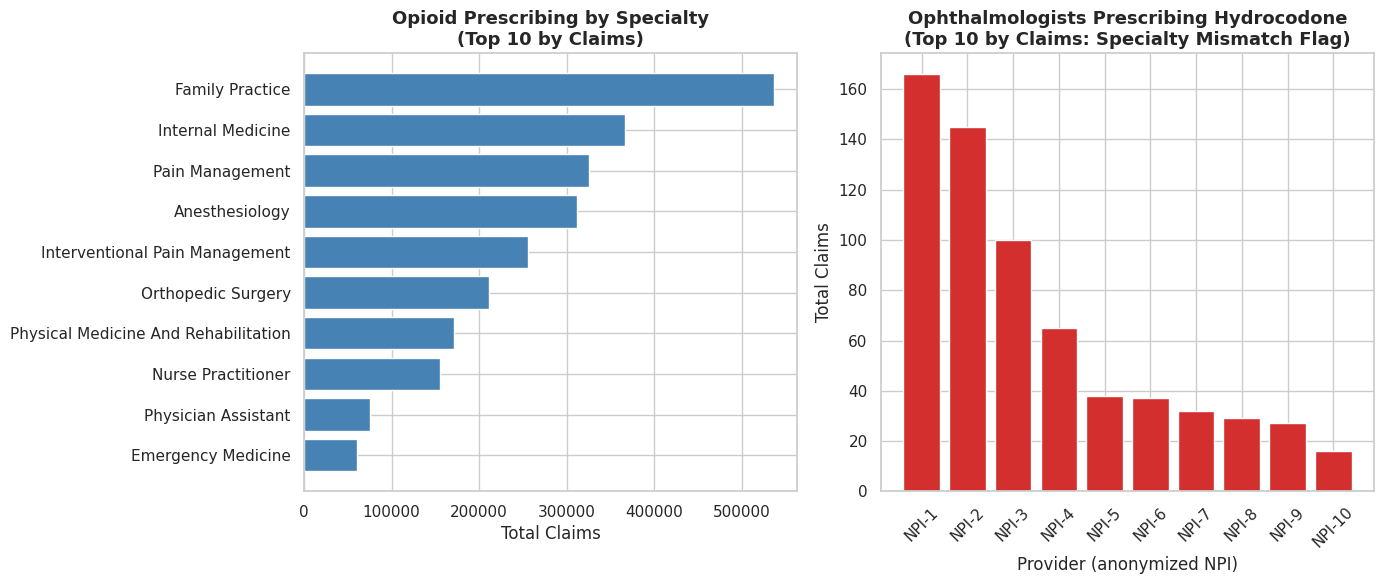

Chart saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: Opioid prescribing by specialty
opioid_df = df[df['Gnrc_Name'].str.lower().str.contains(
    'oxycodone|hydrocodone|fentanyl|morphine|tramadol', na=False)]

opioid_by_specialty = opioid_df.groupby('Prscrbr_Type').agg(
    providers=('Prscrbr_NPI', 'nunique'),
    total_claims=('Tot_Clms', 'sum'),
    total_cost=('Tot_Drug_Cst', 'sum')
).reset_index().nlargest(10, 'total_claims')

axes[0].barh(opioid_by_specialty['Prscrbr_Type'], 
             opioid_by_specialty['total_claims'],
             color='steelblue')
axes[0].set_title('Opioid Prescribing by Specialty\n(Top 10 by Claims)', 
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Claims')
axes[0].invert_yaxis()

# Right: Highlight ophthalmology opioid prescribers
ophtho_opioid = df[
    (df['Prscrbr_Type'] == 'Ophthalmology') &
    (df['Gnrc_Name'].str.lower().str.contains('hydrocodone', na=False))
]

ophtho_summary = ophtho_opioid.groupby('Prscrbr_NPI').agg(
    total_claims=('Tot_Clms', 'sum'),
    total_cost=('Tot_Drug_Cst', 'sum')
).reset_index().nlargest(10, 'total_claims')

axes[1].bar(range(len(ophtho_summary)), 
            ophtho_summary['total_claims'],
            color='#d32f2f')
axes[1].set_title('Ophthalmologists Prescribing Hydrocodone\n(Top 10 by Claims: Specialty Mismatch Flag)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Provider (anonymized NPI)')
axes[1].set_ylabel('Total Claims')
axes[1].set_xticks(range(len(ophtho_summary)))
axes[1].set_xticklabels([f'NPI-{i+1}' for i in range(len(ophtho_summary))], rotation=45)

plt.tight_layout()
plt.savefig('../visualizations/charts/specialty_mismatch_opioids.png', dpi=150)
plt.show()
print("Chart saved")